In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
# Load dataset
df = pd.read_csv('Messy_Employee_dataset.csv')
print(df.head())

  Employee_ID First_Name Last_Name   Age   Department_Region    Status  \
0     EMP1000        Bob     Davis  25.0   DevOps-California    Active   
1     EMP1001        Bob     Brown   NaN       Finance-Texas    Active   
2     EMP1002      Alice     Jones   NaN        Admin-Nevada   Pending   
3     EMP1003        Eva     Davis  25.0        Admin-Nevada  Inactive   
4     EMP1004      Frank  Williams  25.0  Cloud Tech-Florida    Active   

    Join_Date     Salary                       Email       Phone  \
0    4/2/2021   59767.65       bob.davis@example.com -1651623197   
1   7/10/2020   65304.66       bob.brown@example.com -1898471390   
2   12/7/2023   88145.90     alice.jones@example.com -5596363211   
3  11/27/2021   69450.99       eva.davis@example.com -3476490784   
4    1/5/2022  109324.61  frank.williams@example.com -1586734256   

  Performance_Score  Remote_Work  
0           Average         True  
1         Excellent         True  
2              Good         True  
3     

In [64]:
# Check data types and missing values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        1020 non-null   object 
 1   First_Name         1020 non-null   object 
 2   Last_Name          1020 non-null   object 
 3   Age                809 non-null    float64
 4   Department_Region  1020 non-null   object 
 5   Status             1020 non-null   object 
 6   Join_Date          1020 non-null   object 
 7   Salary             996 non-null    float64
 8   Email              1020 non-null   object 
 9   Phone              1020 non-null   int64  
 10  Performance_Score  1020 non-null   object 
 11  Remote_Work        1020 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(8)
memory usage: 88.8+ KB
None


In [65]:
# Counting missing values per column
df.isnull().sum()

Employee_ID            0
First_Name             0
Last_Name              0
Age                  211
Department_Region      0
Status                 0
Join_Date              0
Salary                24
Email                  0
Phone                  0
Performance_Score      0
Remote_Work            0
dtype: int64

In [66]:
# Counting duplicate rows
df.duplicated().sum()

np.int64(0)

In [67]:
# See min/max/mean to spot outliers
df.describe()

,Age,Salary,Phone
count,809.000000,996.000000,1.020000e+03
mean,32.484549,85155.056396,-4.942253e+09
std,5.656860,19873.727918,2.817326e+09
min,25.000000,50047.320000,-9.994973e+09
25%,25.000000,68392.487500,-7.341992e+09
50%,30.000000,85547.870000,-4.943997e+09
75%,40.000000,100974.027500,-2.520391e+09
max,40.000000,119971.650000,-3.896086e+06


In [68]:
# Convert the strings and remove the decimals 
df['Phone'] = df['Phone'].astype('Int64').astype(str)
#Remove negatives and any weird .0 at the end
df['Phone'] = df['Phone'].str.replace('-', '', regex=False)
df['Phone'] = df['Phone'].str.replace('.0', '', regex=False)

In [69]:
# Join date should be in datetime not an object 
df['Join_Date'] = pd.to_datetime(df['Join_Date'], errors = 'coerce')
print(df.head())

  Employee_ID First_Name Last_Name   Age   Department_Region    Status  \
0     EMP1000        Bob     Davis  25.0   DevOps-California    Active   
1     EMP1001        Bob     Brown   NaN       Finance-Texas    Active   
2     EMP1002      Alice     Jones   NaN        Admin-Nevada   Pending   
3     EMP1003        Eva     Davis  25.0        Admin-Nevada  Inactive   
4     EMP1004      Frank  Williams  25.0  Cloud Tech-Florida    Active   

   Join_Date     Salary                       Email       Phone  \
0 2021-04-02   59767.65       bob.davis@example.com  1651623197   
1 2020-07-10   65304.66       bob.brown@example.com  1898471390   
2 2023-12-07   88145.90     alice.jones@example.com  5596363211   
3 2021-11-27   69450.99       eva.davis@example.com  3476490784   
4 2022-01-05  109324.61  frank.williams@example.com  1586734256   

  Performance_Score  Remote_Work  
0           Average         True  
1         Excellent         True  
2              Good         True  
3           

In [70]:
# Age and salary should be numeric
df['Age'] = pd.to_numeric(df['Age'], errors = 'coerce')
df['Salary'] = pd.to_numeric(df['Salary'], errors = 'coerce')

In [71]:
# Fill Age and Salary columns with median so that the outliers do not skew it 
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

In [72]:
print(df.head()) # Checking if the changes that were made are showing up in the code 

  Employee_ID First_Name Last_Name   Age   Department_Region    Status  \
0     EMP1000        Bob     Davis  25.0   DevOps-California    Active   
1     EMP1001        Bob     Brown  30.0       Finance-Texas    Active   
2     EMP1002      Alice     Jones  30.0        Admin-Nevada   Pending   
3     EMP1003        Eva     Davis  25.0        Admin-Nevada  Inactive   
4     EMP1004      Frank  Williams  25.0  Cloud Tech-Florida    Active   

   Join_Date     Salary                       Email       Phone  \
0 2021-04-02   59767.65       bob.davis@example.com  1651623197   
1 2020-07-10   65304.66       bob.brown@example.com  1898471390   
2 2023-12-07   88145.90     alice.jones@example.com  5596363211   
3 2021-11-27   69450.99       eva.davis@example.com  3476490784   
4 2022-01-05  109324.61  frank.williams@example.com  1586734256   

  Performance_Score  Remote_Work  
0           Average         True  
1         Excellent         True  
2              Good         True  
3           

In [73]:
df.isnull().sum() # Checking if all the missing values are handled 

Employee_ID          0
First_Name           0
Last_Name            0
Age                  0
Department_Region    0
Status               0
Join_Date            0
Salary               0
Email                0
Phone                0
Performance_Score    0
Remote_Work          0
dtype: int64

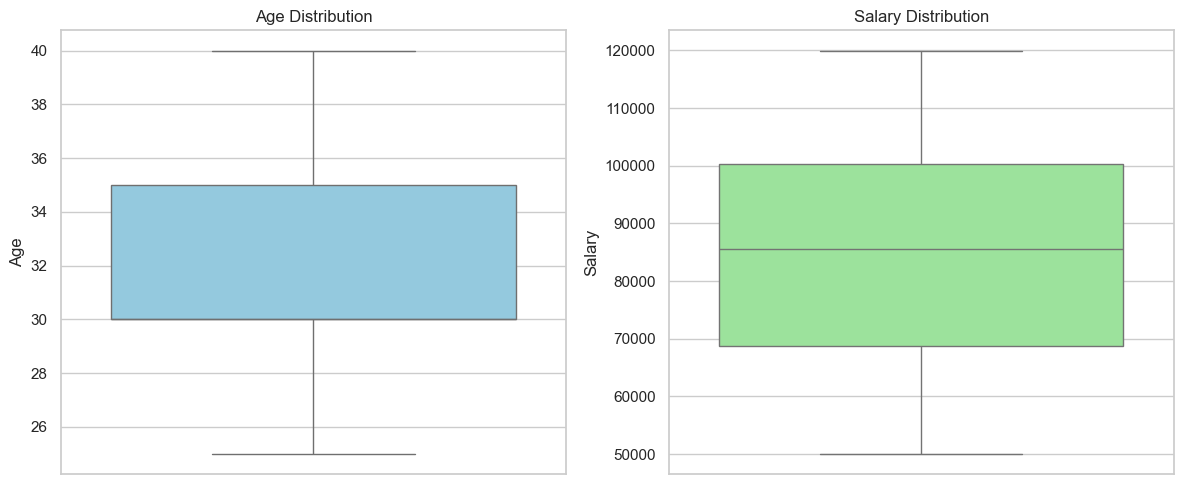

In [74]:
# Verifying if there are no outliers in any of them 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['Age'], ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.boxplot(y=df['Salary'], ax=axes[1], color='lightgreen')
axes[1].set_title('Salary Distribution')

plt.tight_layout()
plt.show()

In [75]:
# Double checking if everything have been fixed
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Employee_ID        1020 non-null   object        
 1   First_Name         1020 non-null   object        
 2   Last_Name          1020 non-null   object        
 3   Age                1020 non-null   float64       
 4   Department_Region  1020 non-null   object        
 5   Status             1020 non-null   object        
 6   Join_Date          1020 non-null   datetime64[ns]
 7   Salary             1020 non-null   float64       
 8   Email              1020 non-null   object        
 9   Phone              1020 non-null   object        
 10  Performance_Score  1020 non-null   object        
 11  Remote_Work        1020 non-null   bool          
dtypes: bool(1), datetime64[ns](1), float64(2), object(8)
memory usage: 88.8+ KB
None


In [76]:
print(f"Rows, Cols: {df.shape}")
print(df[['Age', 'Salary']].describe().round(1))
print("\nCounts by category:")
print(df['Department_Region'].value_counts())
print(df['Remote_Work'].value_counts())
print(df['Status'].value_counts())

Rows, Cols: (1020, 12)
          Age    Salary
count  1020.0    1020.0
mean     32.0   85164.3
std       5.1   19638.4
min      25.0   50047.3
25%      30.0   68811.2
50%      30.0   85547.9
75%      35.0  100372.7
max      40.0  119971.6

Counts by category:
Department_Region
HR-Florida               41
DevOps-California        35
Sales-Nevada             35
Admin-Nevada             34
Admin-California         34
DevOps-Florida           34
Sales-Florida            33
DevOps-Illinois          33
HR-New York              33
Finance-Illinois         33
DevOps-New York          33
Finance-California       32
Sales-California         31
Sales-Illinois           30
Cloud Tech-Texas         29
Admin-Illinois           29
Finance-Nevada           29
Cloud Tech-California    29
Finance-Texas            29
Cloud Tech-Florida       28
DevOps-Texas             27
DevOps-Nevada            27
HR-California            26
Sales-New York           26
Admin-Florida            25
HR-Nevada             

In [77]:
# Region vs Salary - "Which region pays the most?"

region_salary= df.groupby('Department_Region').agg(Avg_Salary=('Salary', 'mean'), Headcount=('Employee_ID', 'count')).round(0).sort_values('Avg_Salary', ascending=False)
print(region_salary)

                       Avg_Salary  Headcount
Department_Region                           
Admin-Illinois            92051.0         29
Cloud Tech-Florida        91715.0         28
Sales-Florida             90583.0         33
DevOps-Nevada             90002.0         27
Admin-California          89564.0         34
Finance-New York          89159.0         23
Sales-California          88534.0         31
HR-Texas                  88007.0         23
HR-California             87745.0         26
HR-Illinois               87708.0         24
Finance-California        87420.0         32
DevOps-Florida            87116.0         34
Sales-Illinois            86982.0         30
DevOps-Texas              86467.0         27
HR-New York               86257.0         33
Admin-Florida             86077.0         25
HR-Nevada                 85850.0         24
Cloud Tech-Nevada         85820.0         20
DevOps-Illinois           85678.0         33
Sales-Texas               85526.0         23
Cloud Tech

In [78]:
# Remote vs Salary - "Does Remote jobs pay more?"
remote_salary = df.groupby('Remote_Work')['Salary'].mean().round(0)
print(remote_salary)
print(f"\nGap: {remote_salary[True] - remote_salary[False]:,.0f}")

Remote_Work
False    85835.0
True     84501.0
Name: Salary, dtype: float64

Gap: -1,334


In [79]:
# Age vs Salary - "Do older people earn more?"
age_salary_corr = df[['Age', 'Salary']].corr().round(2)
print(age_salary_corr)

         Age  Salary
Age     1.00    0.08
Salary  0.08    1.00


In [80]:
# Is the remote pay gap true in every region?"
pivot = pd.pivot_table(df, values='Salary', index='Department_Region', columns='Remote_Work', aggfunc='mean').round(0)
print(pivot)

Remote_Work              False    True 
Department_Region                      
Admin-California       88686.0  90345.0
Admin-Florida          79245.0  93478.0
Admin-Illinois         89766.0  94499.0
Admin-Nevada           80242.0  80921.0
Admin-New York         72578.0  87842.0
Admin-Texas            89215.0  76788.0
Cloud Tech-California  82005.0  85400.0
Cloud Tech-Florida     89577.0  93569.0
Cloud Tech-Illinois    84474.0  85700.0
Cloud Tech-Nevada      86190.0  85451.0
Cloud Tech-New York    77841.0  79017.0
Cloud Tech-Texas       85553.0  83700.0
DevOps-California      85166.0  80756.0
DevOps-Florida         93315.0  84534.0
DevOps-Illinois        81974.0  88766.0
DevOps-Nevada          91900.0  87957.0
DevOps-New York        89297.0  80877.0
DevOps-Texas           89516.0  80370.0
Finance-California     91208.0  81883.0
Finance-Florida        81323.0  84874.0
Finance-Illinois       76427.0  75108.0
Finance-Nevada         86230.0  70390.0
Finance-New York       85774.0  92853.0


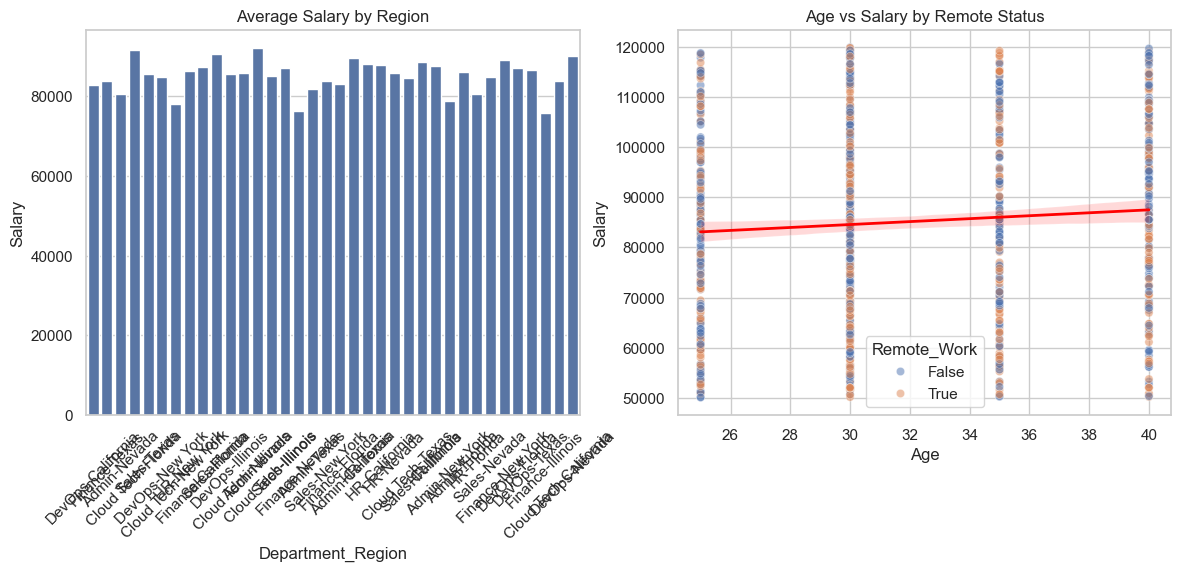

In [81]:
sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# chart 1: Bar for region
sns.barplot(x='Department_Region', y='Salary', data=df, estimator='mean', errorbar=None, ax=ax[0])
ax[0].set_title('Average Salary by Region')
ax[0].tick_params(axis='x', rotation=45)

# Chart 2: Scatter for Age vs Salary, colored by Remote
sns.scatterplot(x='Age', y='Salary', hue='Remote_Work', data=df, ax=ax[1], alpha=0.5)
sns.regplot(x='Age', y='Salary', data=df, scatter=False, ax=ax[1], color='red', line_kws={'linewidth':2})
ax[1].set_title('Age vs Salary by Remote Status')
plt.show()

Coverage: 
Dataset = 1020 employees across 14+ department/region combinations. 
Ages range from 25 to 40, avg 32 years old.
Average salary is $85,164, with no missing values and balanced regional coverage.

Key trend:
Admin-Illinois has the highest average salary at ~$94,499 for remote roles, while Finance-Illlinois is lowest at $75,708.
Age and Salary have a weak relationship [corr = 0.08], so older age does not mean higher pay here. 

Nuance:
Contrary to expectations, in-office employees earn $1,344 more on average than remote employees.
The pivot table shows this isn't consistent: remote payes more in some regions like Admin-California, but in-office pays more in others. The remote gap depends on region.